# `net_fish_sonar_improved` — Dataset Statistics

Visual summary of the processed split: class balance, scale variance, objects-per-image distribution, and instance placement heatmaps.

**Classes:** `0 = fish`, `1 = net`  
**Image size:** 1200 × 700 px  
**Splits:** train / val / test (bag-disjoint)

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec

# ── paths ────────────────────────────────────────────────────────────────────
PROCESSED = Path("processed")
IMG_W, IMG_H = 1200, 700
SPLITS = ["train", "val", "test"]
CLASS_NAMES  = {0: "fish", 1: "net"}
CLASS_COLORS = {0: "#E84855", 1: "#3A86FF"}   # fish=red, net=blue
SPLIT_COLORS = {"train": "#2E86AB", "val": "#F18F01", "test": "#A23B72"}

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── load all YOLO label files ────────────────────────────────────────────────
records = []
for split in SPLITS:
    lbl_dir = PROCESSED / "labels" / split
    img_dir = PROCESSED / "images" / split
    for lbl_path in sorted(lbl_dir.glob("*.txt")):
        text = lbl_path.read_text(encoding="utf-8").strip()
        lines = [l for l in text.splitlines() if l.strip()]
        for line in lines:
            parts = line.split()
            cls = int(parts[0])
            xc, yc, wn, hn = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            records.append({
                "split":    split,
                "image":    lbl_path.stem,
                "class_id": cls,
                "class":    CLASS_NAMES[cls],
                "xc":       xc,
                "yc":       yc,
                "wn":       wn,
                "hn":       hn,
                "area_norm": wn * hn,
                "w_px":     wn * IMG_W,
                "h_px":     hn * IMG_H,
                "area_px":  wn * hn * IMG_W * IMG_H,
            })

df = pd.DataFrame(records)

# per-image summary (for objects-per-image stats)
img_records = []
for split in SPLITS:
    lbl_dir = PROCESSED / "labels" / split
    for lbl_path in sorted(lbl_dir.glob("*.txt")):
        text = lbl_path.read_text(encoding="utf-8").strip()
        lines = [l for l in text.splitlines() if l.strip()]
        counts = Counter(int(l.split()[0]) for l in lines)
        img_records.append({
            "split":    split,
            "image":    lbl_path.stem,
            "n_fish":   counts.get(0, 0),
            "n_net":    counts.get(1, 0),
            "n_total":  sum(counts.values()),
        })

df_img = pd.DataFrame(img_records)

print(f"Instances loaded : {len(df):,}")
print(f"Images loaded    : {len(df_img):,}")
print(df.groupby(["split", "class"])["class"].count().unstack(fill_value=0))

Instances loaded : 3,079
Images loaded    : 2,136
class  fish   net
split            
test    165   400
train   637  1336
val     141   400


## 1 — Dataset overview

,Images,Fish instances,Net instances,Total instances,Images w/ fish,Avg fish/img
Split,,,,,,
train,1336,637,1336,1973,418,1.52
val,400,141,400,541,58,2.43
test,400,165,400,565,70,2.36
TOTAL,2136,943,2136,3079,546,1.73


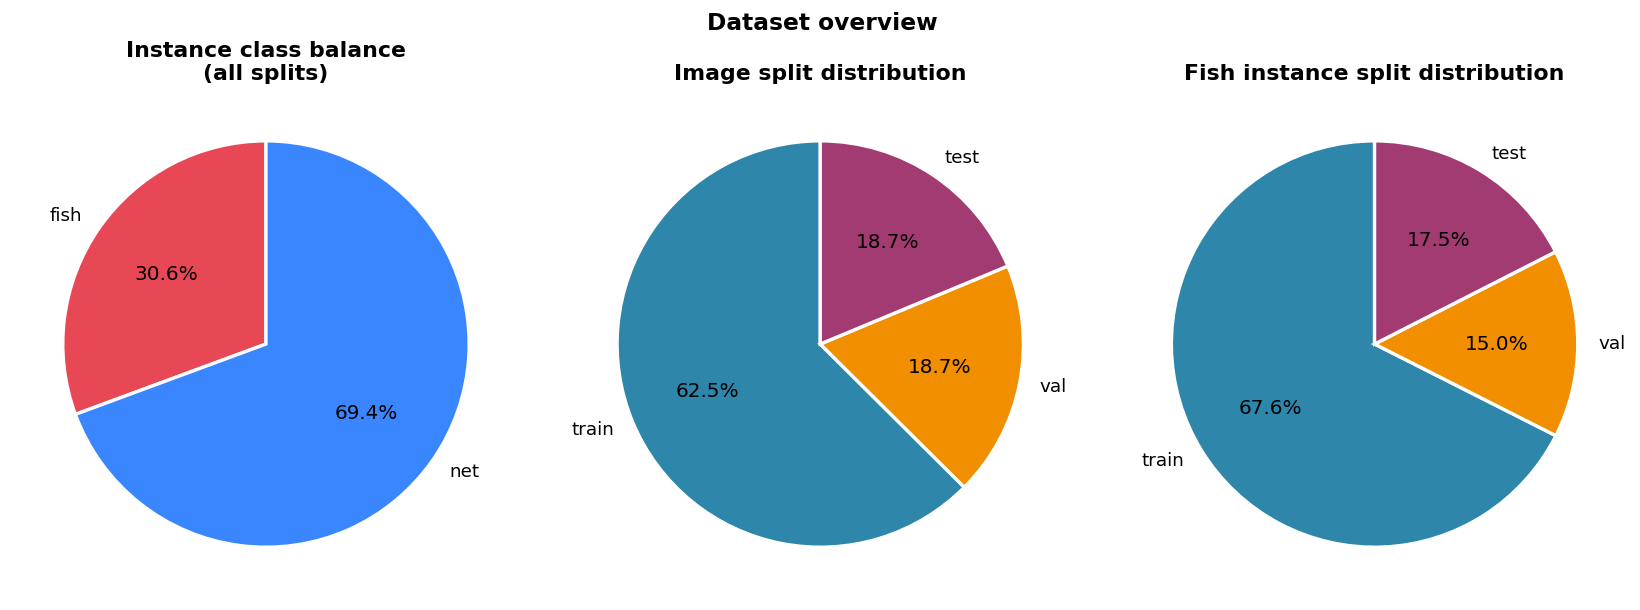

In [2]:
# ── summary table ────────────────────────────────────────────────────────────
rows = []
for split in SPLITS:
    sub  = df[df["split"] == split]
    imgs = df_img[df_img["split"] == split]
    rows.append({
        "Split":           split,
        "Images":          len(imgs),
        "Fish instances":  int((sub["class_id"] == 0).sum()),
        "Net instances":   int((sub["class_id"] == 1).sum()),
        "Total instances": len(sub),
        "Images w/ fish":  int((imgs["n_fish"] > 0).sum()),
        "Avg fish/img":    round(sub[sub["class_id"]==0].groupby("image").size().mean() if (sub["class_id"]==0).any() else 0, 2),
    })
totals = {
    "Split": "TOTAL",
    "Images":          len(df_img),
    "Fish instances":  int((df["class_id"] == 0).sum()),
    "Net instances":   int((df["class_id"] == 1).sum()),
    "Total instances": len(df),
    "Images w/ fish":  int((df_img["n_fish"] > 0).sum()),
    "Avg fish/img":    round(df[df["class_id"]==0].groupby("image").size().mean(), 2),
}
rows.append(totals)
display(pd.DataFrame(rows).set_index("Split"))

# ── pie charts: class balance & split distribution ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# (a) instance class balance (all splits)
class_counts = df.groupby("class_id").size()
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    class_counts.values,
    labels=[CLASS_NAMES[i] for i in class_counts.index],
    colors=[CLASS_COLORS[i] for i in class_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts: at.set_fontsize(12)
ax.set_title("Instance class balance\n(all splits)", fontweight="bold")

# (b) image split distribution
split_img_counts = df_img.groupby("split").size().reindex(SPLITS)
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    split_img_counts.values,
    labels=SPLITS,
    colors=[SPLIT_COLORS[s] for s in SPLITS],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts: at.set_fontsize(12)
ax.set_title("Image split distribution", fontweight="bold")

# (c) fish-instance split distribution
fish_split = df[df["class_id"]==0].groupby("split").size().reindex(SPLITS, fill_value=0)
ax = axes[2]
wedges, texts, autotexts = ax.pie(
    fish_split.values,
    labels=SPLITS,
    colors=[SPLIT_COLORS[s] for s in SPLITS],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts: at.set_fontsize(12)
ax.set_title("Fish instance split distribution", fontweight="bold")

plt.suptitle("Dataset overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 2 — Objects per image

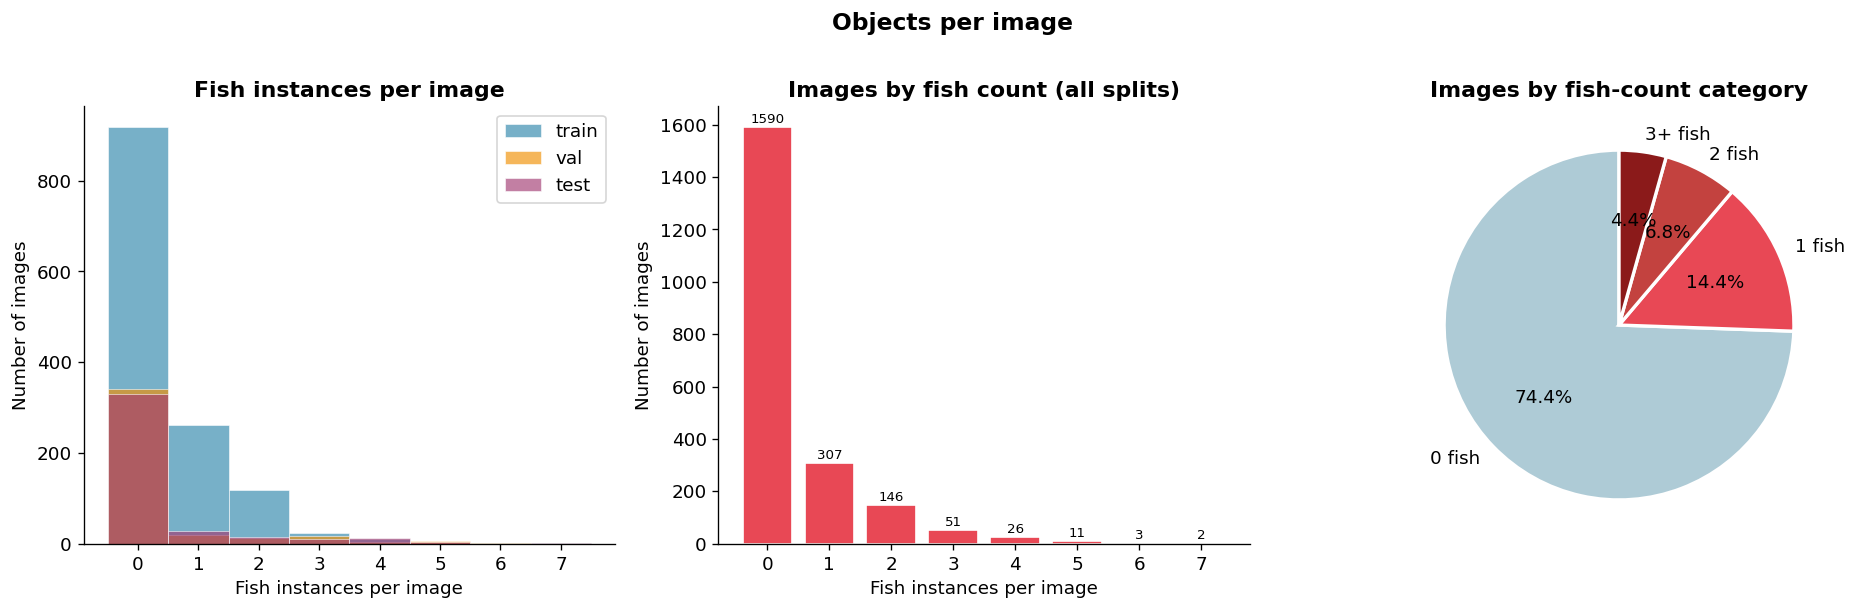

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (a) fish instances per image — histogram across splits ───────────────────
ax = axes[0]
max_fish = df_img["n_fish"].max()
bins = np.arange(0, max_fish + 2) - 0.5
for split in SPLITS:
    vals = df_img[df_img["split"] == split]["n_fish"]
    ax.hist(vals, bins=bins, alpha=0.65, label=split,
            color=SPLIT_COLORS[split], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Fish instances per image")
ax.set_ylabel("Number of images")
ax.set_title("Fish instances per image", fontweight="bold")
ax.legend()
ax.set_xticks(range(0, max_fish + 1))

# ── (b) total instances per image — stacked bar by class ────────────────────
ax = axes[1]
max_total = df_img["n_total"].max()
count_range = range(0, max_total + 1)
# net is always 1 per image, so total = 1 + n_fish
fish_freq  = df_img["n_fish"].value_counts().sort_index()
n_imgs_per_fish = [fish_freq.get(k, 0) for k in range(0, max_fish + 1)]
bar_x = np.arange(0, max_fish + 1)
ax.bar(bar_x, n_imgs_per_fish, color=CLASS_COLORS[0], label="fish", edgecolor="white")
ax.set_xlabel("Fish instances per image")
ax.set_ylabel("Number of images")
ax.set_title("Images by fish count (all splits)", fontweight="bold")
ax.set_xticks(bar_x)
for x, v in zip(bar_x, n_imgs_per_fish):
    if v > 0:
        ax.text(x, v + 5, str(v), ha="center", va="bottom", fontsize=8)

# ── (c) pie: images by fish count category ──────────────────────────────────
ax = axes[2]
def fish_cat(n):
    if n == 0: return "0 fish"
    if n == 1: return "1 fish"
    if n == 2: return "2 fish"
    return "3+ fish"

df_img["fish_cat"] = df_img["n_fish"].apply(fish_cat)
cat_order  = ["0 fish", "1 fish", "2 fish", "3+ fish"]
cat_colors = ["#AECBD6", "#E84855", "#C3423F", "#8B1A1A"]
cat_counts = df_img["fish_cat"].value_counts().reindex(cat_order, fill_value=0)

# only show non-zero slices
mask = cat_counts > 0
wedges, texts, autotexts = ax.pie(
    cat_counts[mask].values,
    labels=cat_counts[mask].index.tolist(),
    colors=[c for c, m in zip(cat_colors, mask) if m],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts: at.set_fontsize(11)
ax.set_title("Images by fish-count category", fontweight="bold")

plt.suptitle("Objects per image", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3 — Scale variance (bounding box sizes)

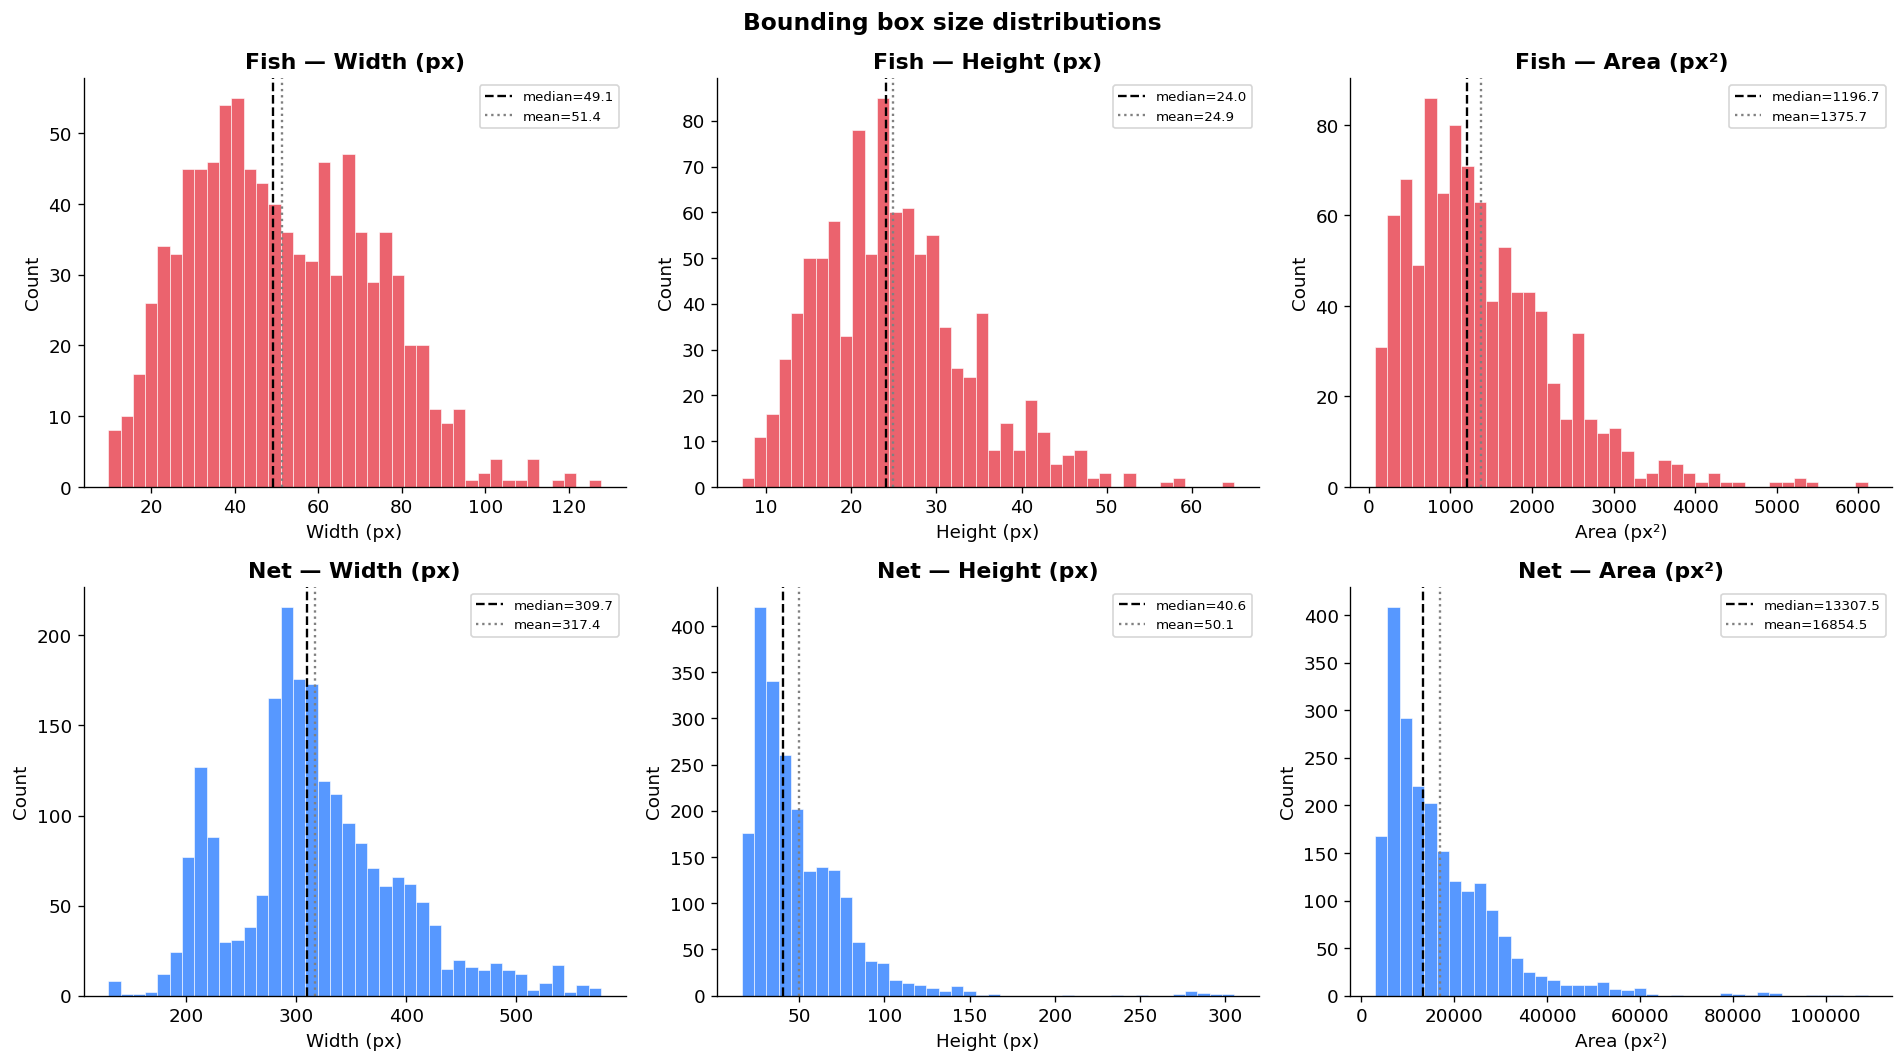

In [4]:
fish = df[df["class_id"] == 0]
net  = df[df["class_id"] == 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── row 0: fish ──────────────────────────────────────────────────────────────
for col, (key, label) in enumerate([("w_px", "Width (px)"), ("h_px", "Height (px)"), ("area_px", "Area (px²)")]):
    ax = axes[0, col]
    vals = fish[key]
    ax.hist(vals, bins=40, color=CLASS_COLORS[0], alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.axvline(vals.median(), color="black", linestyle="--", linewidth=1.4, label=f"median={vals.median():.1f}")
    ax.axvline(vals.mean(),   color="gray",  linestyle=":",  linewidth=1.4, label=f"mean={vals.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Fish — {label}", fontweight="bold")
    ax.legend(fontsize=8)

# ── row 1: net ───────────────────────────────────────────────────────────────
for col, (key, label) in enumerate([("w_px", "Width (px)"), ("h_px", "Height (px)"), ("area_px", "Area (px²)")]):
    ax = axes[1, col]
    vals = net[key]
    ax.hist(vals, bins=40, color=CLASS_COLORS[1], alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.axvline(vals.median(), color="black", linestyle="--", linewidth=1.4, label=f"median={vals.median():.1f}")
    ax.axvline(vals.mean(),   color="gray",  linestyle=":",  linewidth=1.4, label=f"mean={vals.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Net — {label}", fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Bounding box size distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

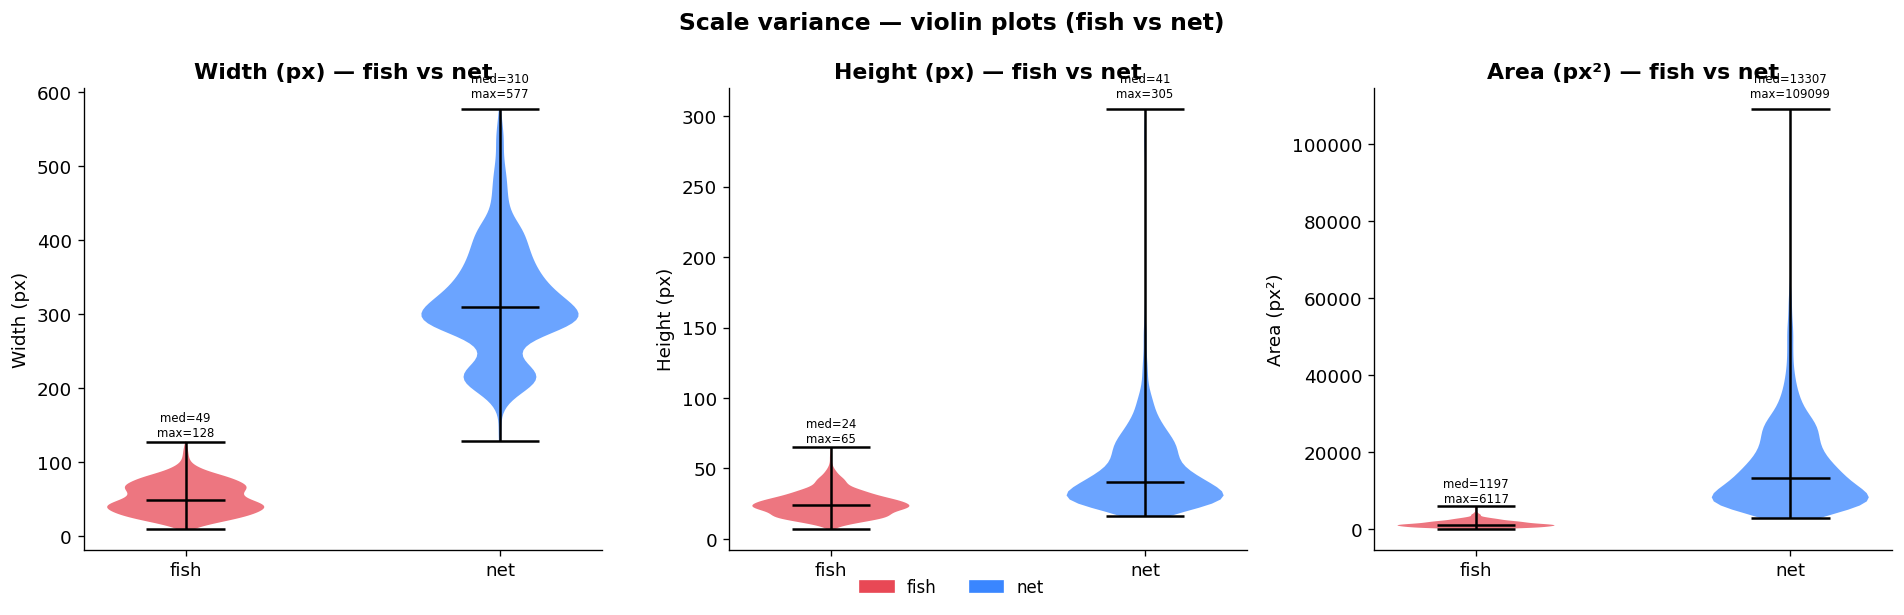

In [5]:
# ── violin / box comparison of bbox area per class ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ("w_px",    "Width (px)"),
    ("h_px",    "Height (px)"),
    ("area_px", "Area (px²)"),
]

for ax, (key, label) in zip(axes, metrics):
    data_fish = fish[key].values
    data_net  = net[key].values

    parts = ax.violinplot(
        [data_fish, data_net], positions=[0, 1],
        showmedians=True, showextrema=True,
    )
    for pc, color in zip(parts["bodies"], [CLASS_COLORS[0], CLASS_COLORS[1]]):
        pc.set_facecolor(color)
        pc.set_alpha(0.75)
    parts["cmedians"].set_color("black")
    parts["cbars"].set_color("black")
    parts["cmins"].set_color("black")
    parts["cmaxes"].set_color("black")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["fish", "net"])
    ax.set_ylabel(label)
    ax.set_title(f"{label} — fish vs net", fontweight="bold")

    # annotate with stats
    for pos, vals in [(0, data_fish), (1, data_net)]:
        ax.text(pos, vals.max() * 1.02,
                f"med={np.median(vals):.0f}\nmax={vals.max():.0f}",
                ha="center", va="bottom", fontsize=7)

patch_fish = mpatches.Patch(color=CLASS_COLORS[0], label="fish")
patch_net  = mpatches.Patch(color=CLASS_COLORS[1], label="net")
fig.legend(handles=[patch_fish, patch_net], loc="lower center", ncol=2,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Scale variance — violin plots (fish vs net)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

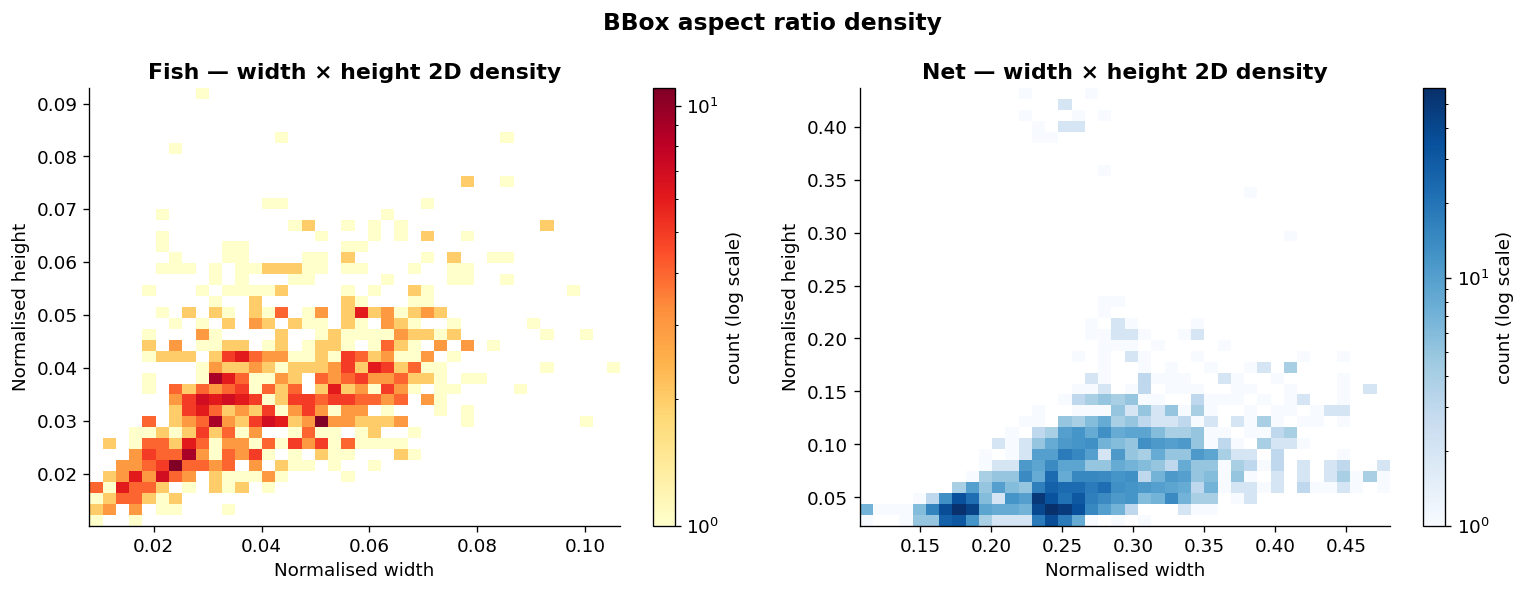

In [6]:
# ── 2D scatter: bbox width vs height (normalised) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (cls_id, cls_name) in zip(axes, CLASS_NAMES.items()):
    sub = df[df["class_id"] == cls_id]
    h = ax.hist2d(
        sub["wn"], sub["hn"],
        bins=40,
        norm=LogNorm(),
        cmap="YlOrRd" if cls_id == 0 else "Blues",
    )
    plt.colorbar(h[3], ax=ax, label="count (log scale)")
    ax.set_xlabel("Normalised width")
    ax.set_ylabel("Normalised height")
    ax.set_title(f"{cls_name.capitalize()} — width × height 2D density", fontweight="bold")

plt.suptitle("BBox aspect ratio density", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4 — Instance placement heatmaps

Each pixel in the heatmap shows how often a bounding-box **centre** falls in that region (left) and how often the bounding-box **area covers** that region (right), normalised to image coordinates.

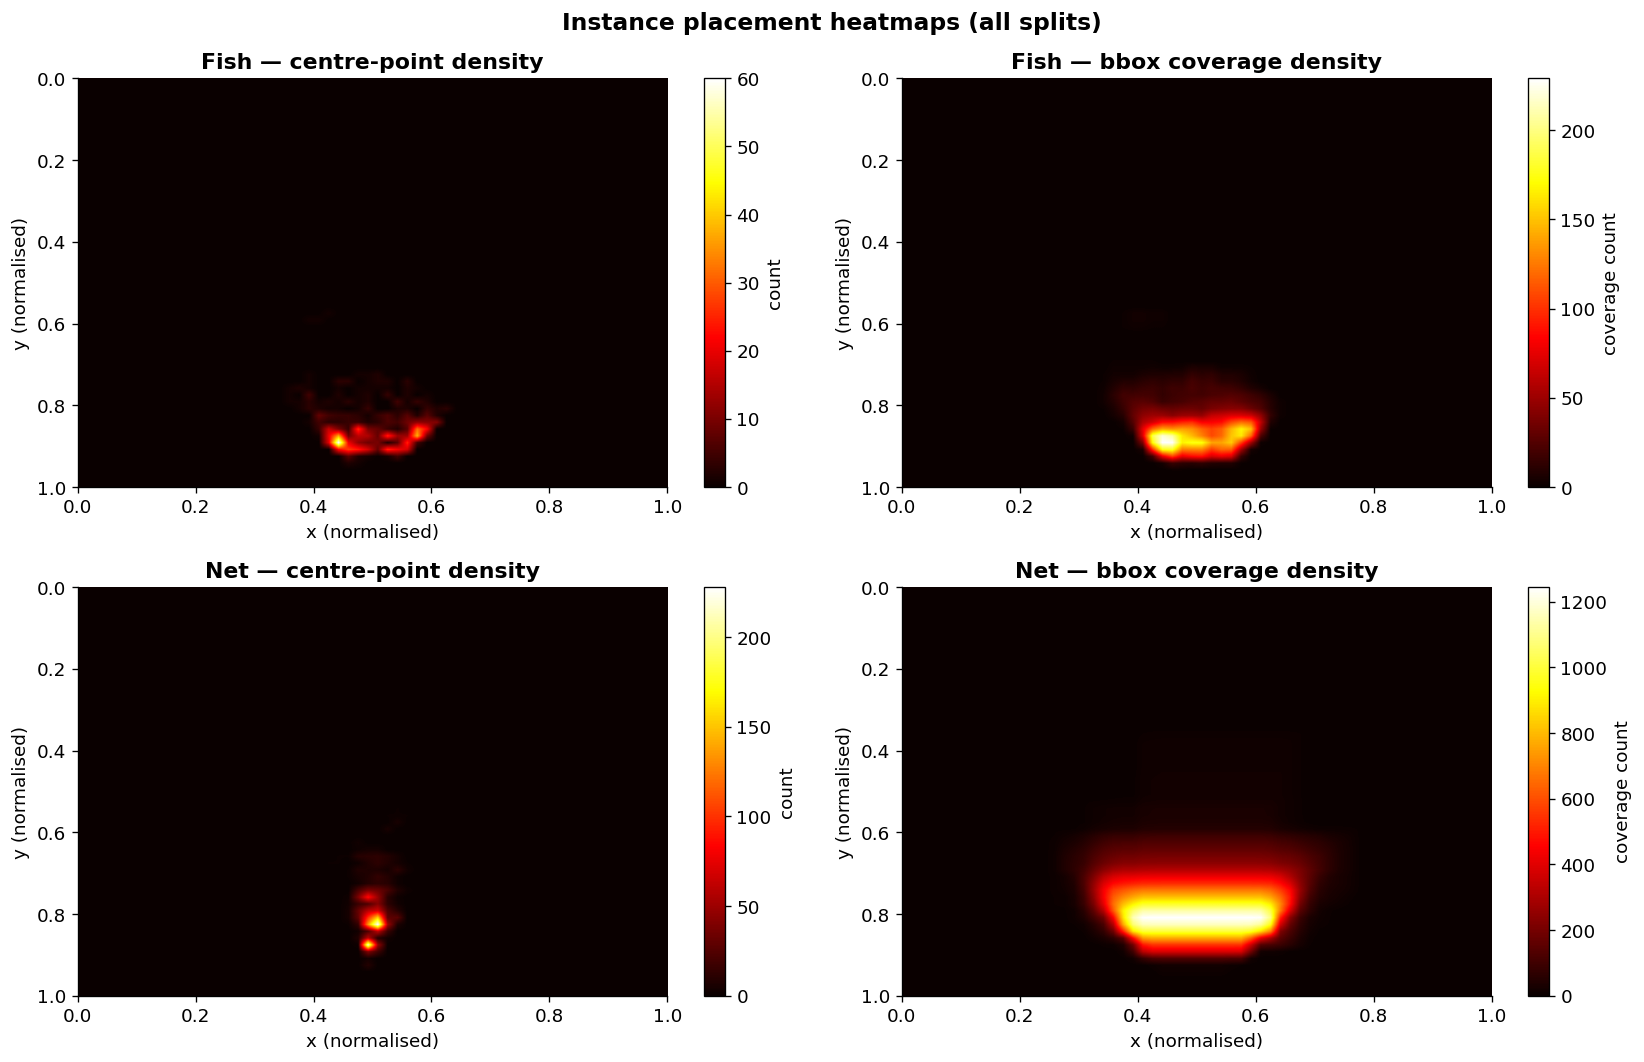

In [7]:
GRID = 60   # heatmap resolution (cells)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, (cls_id, cls_name) in enumerate(CLASS_NAMES.items()):
    sub = df[df["class_id"] == cls_id]

    # ── centre-point heatmap ──────────────────────────────────────────────────
    ax = axes[row, 0]
    h, xedges, yedges = np.histogram2d(
        sub["xc"], sub["yc"],
        bins=GRID, range=[[0, 1], [0, 1]]
    )
    # imshow expects (row=y, col=x)
    im = ax.imshow(
        h.T, origin="upper",
        extent=[0, 1, 1, 0],
        aspect="auto",
        cmap="hot",
        interpolation="bilinear",
    )
    plt.colorbar(im, ax=ax, label="count")
    ax.set_xlabel("x (normalised)")
    ax.set_ylabel("y (normalised)")
    ax.set_title(f"{cls_name.capitalize()} — centre-point density", fontweight="bold")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.invert_yaxis()

    # ── coverage heatmap (how often each grid cell is covered by a bbox) ──────
    ax = axes[row, 1]
    coverage = np.zeros((GRID, GRID), dtype=np.float32)
    xs = np.linspace(0, 1, GRID + 1)
    ys = np.linspace(0, 1, GRID + 1)
    cx = (xs[:-1] + xs[1:]) / 2
    cy = (ys[:-1] + ys[1:]) / 2

    for _, row_data in sub.iterrows():
        x1 = row_data["xc"] - row_data["wn"] / 2
        x2 = row_data["xc"] + row_data["wn"] / 2
        y1 = row_data["yc"] - row_data["hn"] / 2
        y2 = row_data["yc"] + row_data["hn"] / 2
        xi1, xi2 = np.searchsorted(xs, [x1, x2])
        yi1, yi2 = np.searchsorted(ys, [y1, y2])
        xi1 = max(0, xi1 - 1); xi2 = min(GRID, xi2)
        yi1 = max(0, yi1 - 1); yi2 = min(GRID, yi2)
        coverage[xi1:xi2, yi1:yi2] += 1

    im2 = ax.imshow(
        coverage.T, origin="upper",
        extent=[0, 1, 1, 0],
        aspect="auto",
        cmap="hot",
        interpolation="bilinear",
    )
    plt.colorbar(im2, ax=ax, label="coverage count")
    ax.set_xlabel("x (normalised)")
    ax.set_ylabel("y (normalised)")
    ax.set_title(f"{cls_name.capitalize()} — bbox coverage density", fontweight="bold")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.invert_yaxis()

plt.suptitle("Instance placement heatmaps (all splits)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

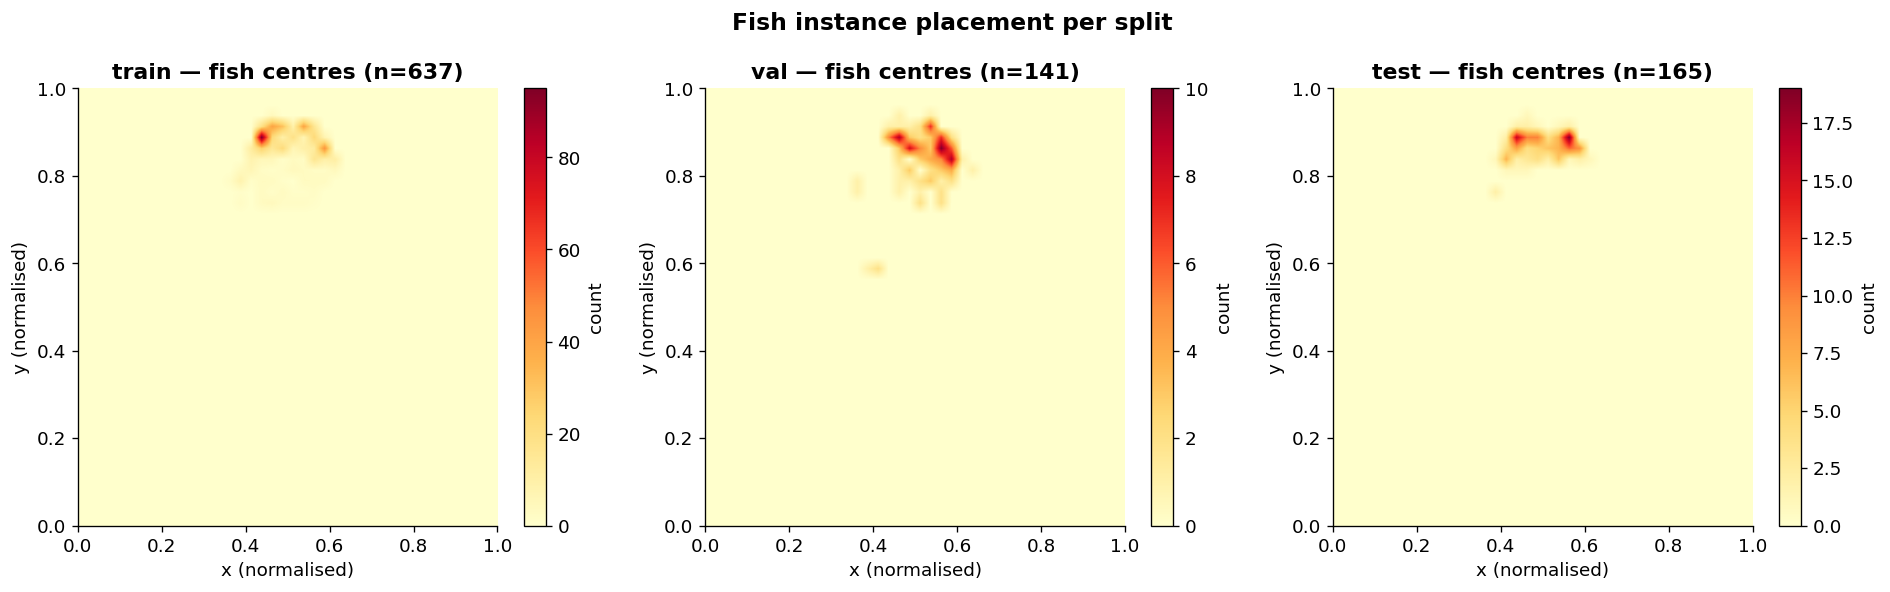

In [8]:
# ── fish centre placement per split (side-by-side) ───────────────────────────
fish_df = df[df["class_id"] == 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, split in zip(axes, SPLITS):
    sub = fish_df[fish_df["split"] == split]
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    h, xedges, yedges = np.histogram2d(
        sub["xc"], sub["yc"],
        bins=40, range=[[0, 1], [0, 1]]
    )
    im = ax.imshow(
        h.T, origin="upper",
        extent=[0, 1, 1, 0],
        aspect="auto",
        cmap="YlOrRd",
        interpolation="bilinear",
    )
    plt.colorbar(im, ax=ax, label="count")
    ax.set_xlabel("x (normalised)")
    ax.set_ylabel("y (normalised)")
    ax.invert_yaxis()
    ax.set_title(f"{split} — fish centres (n={len(sub)})", fontweight="bold")

plt.suptitle("Fish instance placement per split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5 — Per-bag breakdown

,images,fish_total,fish_images,split,avg_fish_per_img,fish_image_rate
bag,,,,,,
bag1,200,85,37,test,0.425,0.185
bag2,200,141,58,val,0.705,0.290
bag3,200,31,25,train,0.155,0.125
bag4,200,127,41,train,0.635,0.205
bag5,200,0,0,val,0.000,0.000
bag6,200,0,0,train,0.000,0.000
bag7,200,22,16,train,0.110,0.080
bag8,200,0,0,train,0.000,0.000
bag9,200,80,33,test,0.400,0.165


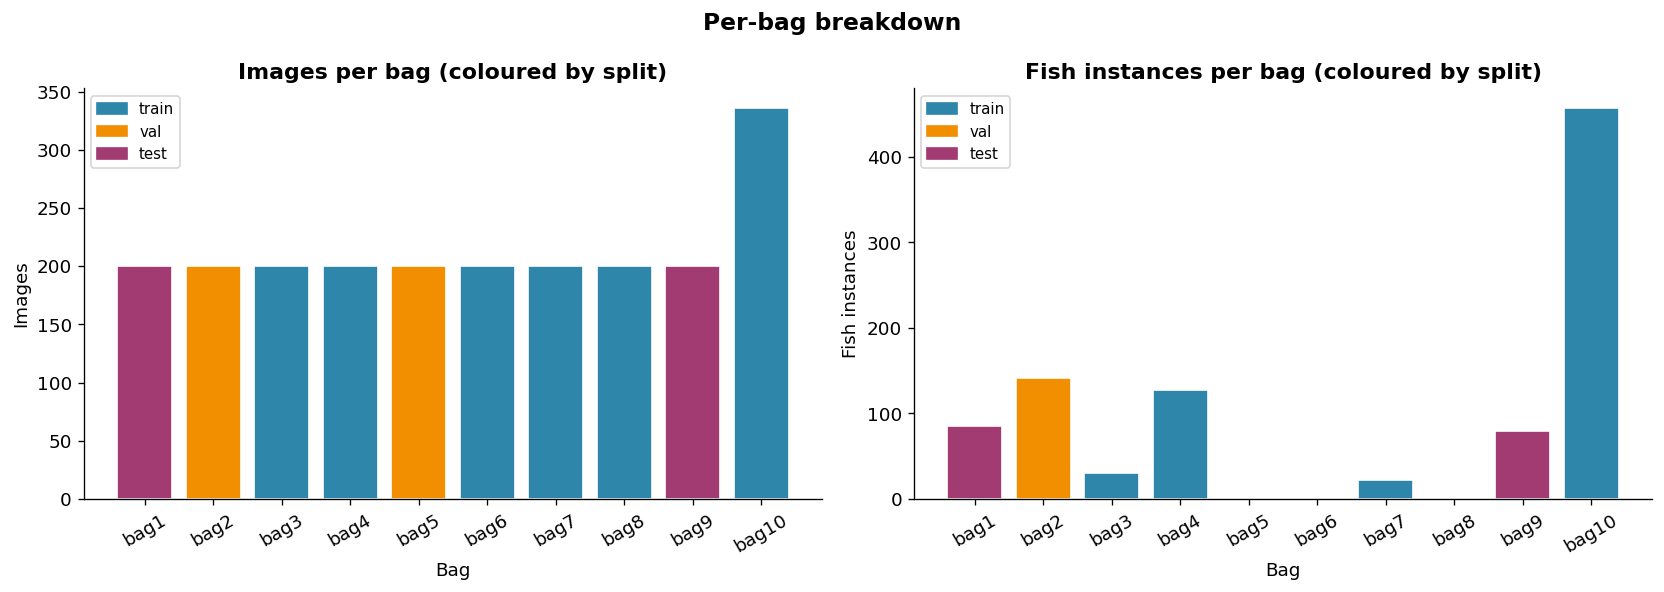

In [9]:
import re

# extract bag id from image stem
df_img["bag"] = df_img["image"].apply(
    lambda s: re.match(r"(bag\d+)_", s).group(1) if re.match(r"(bag\d+)_", s) else "unknown"
)

bag_order = sorted(df_img["bag"].unique(), key=lambda s: int(re.search(r"\d+", s).group()))

bag_stats = (
    df_img.groupby("bag")
    .agg(
        images     =("image",   "count"),
        fish_total =("n_fish",  "sum"),
        fish_images=("n_fish",  lambda x: (x > 0).sum()),
        split      =("split",   "first"),
    )
    .reindex(bag_order)
    .reset_index()
)
bag_stats["avg_fish_per_img"] = (bag_stats["fish_total"] / bag_stats["images"]).round(3)
bag_stats["fish_image_rate"]  = (bag_stats["fish_images"] / bag_stats["images"]).round(3)
display(bag_stats.set_index("bag"))

# ── bar chart: images per bag coloured by split ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bar_colors = [SPLIT_COLORS[row.split] for row in bag_stats.itertuples()]
bars = ax.bar(bag_stats["bag"], bag_stats["images"], color=bar_colors, edgecolor="white")
ax.set_xlabel("Bag")
ax.set_ylabel("Images")
ax.set_title("Images per bag (coloured by split)", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
legend_patches = [mpatches.Patch(color=SPLIT_COLORS[s], label=s) for s in SPLITS]
ax.legend(handles=legend_patches, fontsize=9)

ax = axes[1]
bars = ax.bar(bag_stats["bag"], bag_stats["fish_total"], color=bar_colors, edgecolor="white")
ax.set_xlabel("Bag")
ax.set_ylabel("Fish instances")
ax.set_title("Fish instances per bag (coloured by split)", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.legend(handles=legend_patches, fontsize=9)

plt.suptitle("Per-bag breakdown", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 — Numeric summary

In [10]:
print("=== Fish bbox statistics ===")
display(fish[["w_px", "h_px", "area_px", "area_norm"]].describe().round(2))

print("\n=== Net bbox statistics ===")
display(net[["w_px", "h_px", "area_px", "area_norm"]].describe().round(2))

print("\n=== Fish instances per image (non-zero only) ===")
display(df_img[df_img["n_fish"] > 0]["n_fish"].describe().round(2))

=== Fish bbox statistics ===


,w_px,h_px,area_px,area_norm
count,943.00,943.00,943.00,943.00
mean,51.40,24.91,1375.71,0.00
std,21.46,8.85,892.97,0.00
min,9.70,7.11,74.69,0.00
25%,34.36,18.27,729.20,0.00
50%,49.05,24.03,1196.67,0.00
75%,67.56,30.10,1874.95,0.00
max,127.69,65.01,6116.76,0.01



=== Net bbox statistics ===


,w_px,h_px,area_px,area_norm
count,2136.00,2136.00,2136.00,2136.00
mean,317.35,50.09,16854.51,0.02
std,75.49,31.88,12638.74,0.02
min,128.86,16.25,2914.86,0.00
25%,278.61,30.13,7922.21,0.01
50%,309.66,40.63,13307.49,0.02
75%,359.87,62.69,22271.81,0.03
max,576.95,305.31,109099.11,0.13



=== Fish instances per image (non-zero only) ===


count    546.00
mean       1.73
std        1.07
min        1.00
25%        1.00
50%        1.00
75%        2.00
max        7.00
Name: n_fish, dtype: float64